# ICT-4 — Tableaux chimériques & agrégation émergente (« kin »)

> Série **Integrated Causal Trajectories** ([ICT-0 — cadrage](ICT-0-Framing.md), Epic **#4588**).
> Ce notebook prolonge directement **[ICT-2 — Le tri comme morphogenèse](ICT-2-SelfSortingMorphogenesis.ipynb)**.

Dans [ICT-2](ICT-2-SelfSortingMorphogenesis.ipynb), un tableau dont les cellules se trient elles-mêmes — chacune suivant la règle locale de son *algotype* (`bubble` regarde à droite, `insertion` regarde à gauche) — reproduit fidèlement plusieurs **compétences inattendues** du papier de Zhang, Goldstein & Levin (2025) : robustesse aux cellules défectueuses, délai de gratification, auto-réparation. Mais une compétence *positive* manquait à l'appel : l'**agrégation par « kin »**, ce penchant qu'ont les cellules de même algotype à se regrouper pendant le voyage, sans que cela soit encodé comme objectif. Le modèle minimal produisait au contraire des **impasses** aux frontières `insertion | bubble`. ICT-2 l'a dit honnêtement et a renvoyé l'agrégation à **ce notebook**, « avec un jeu de règles plus riche ».

**La question d'ICT-4.** Quel enrichissement *minimal* des règles locales fait émerger l'agrégation « kin » — sans jamais l'inscrire comme but global, et sans casser le tri ?

Nous procédons en trois temps :

1. **Rappel** de l'impasse chimérique d'ICT-2 (règles minimales).
2. **Réparation bidirectionnelle** : un coup d'œil au second voisin guérit l'impasse — mais ne crée *aucune* agrégation.
3. **Affinité « kin »** : un second élan, *neutre pour l'ordre*, qui s'exprime dans les **degrés de liberté** laissés par le tri. L'agrégation émerge alors — et nous **mesurons** où, quand, et à quelles conditions.

Le fil rouge de la série reste la **discipline d'honnêteté** : exécuter, mesurer, et *narrer le résultat réel* plutôt que celui qu'on espérait.

In [1]:
# --- Imports et configuration ---
import sys, os, random
sys.path.insert(0, os.path.abspath("."))  # le package `ict/` est a cote de ce notebook

import numpy as np
import matplotlib.pyplot as plt

from ict.self_sorting import SelfSortingArray, ALGOTYPES
from ict.kin_sorting import KinSortingArray
from ict import sorting_metrics as m

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

def perm(k, rng):
    """Permutation de 0..k-1 en entiers Python natifs (valeurs distinctes)."""
    return [int(x) for x in rng.permutation(k)]

def value_classes(n_classes, copies, seed=0):
    """Tableau melange ou chaque valeur apparait `copies` fois -- des classes de
    'destins equivalents' pour le tri, qui ouvrent des degres de liberte pour
    l'organisation secondaire. Un algotype aleatoire par cellule."""
    r = random.Random(seed)
    vals = [c for c in range(n_classes) for _ in range(copies)]
    algos = [ALGOTYPES[r.randint(0, 1)] for _ in vals]
    idx = list(range(len(vals))); r.shuffle(idx)
    return [vals[i] for i in idx], [algos[i] for i in idx]

def sorted_with_mixed_algos(n_classes, copies, seed=0):
    """Tableau DEJA trie par valeur, algotypes melanges : l'ordre primaire est
    satisfait, seuls les mouvements 'kin' operent -> agregation isolee."""
    r = random.Random(seed)
    vals = [c for c in range(n_classes) for _ in range(copies)]
    algos = [ALGOTYPES[r.randint(0, 1)] for _ in vals]
    return vals, algos

print("Algotypes :", ALGOTYPES, "| package ict/ charge (SelfSortingArray, KinSortingArray)")

Algotypes : ('bubble', 'insertion') | package ict/ charge (SelfSortingArray, KinSortingArray)


## 1. Rappel : l'impasse chimérique d'ICT-2

`bubble` (pousse les grandes valeurs vers la droite) et `insertion` (tire les petites vers la gauche) servent le **même** ordre croissant. On pourrait croire qu'un tableau **chimérique** — qui mélange les deux — se trie aussi. Vérifions, sur le modèle minimal d'ICT-2, ce qui se passe *vraiment* lorsque les algotypes alternent.

In [2]:
# --- Exemple guide : le modele minimal (ICT-2) sur des tableaux chimeriques alternes ---
N, n_seeds = 20, 40
non_tries, inv_res, agg_fin = 0, [], []
for s in range(n_seeds):
    v = perm(N, np.random.default_rng(s))
    algos = [ALGOTYPES[i % 2] for i in range(N)]            # alternance bubble/insertion
    arr = SelfSortingArray(v, algotypes=algos, seed=s).run()
    if arr.values != sorted(v):
        non_tries += 1
        inv_res.append(m.inversion_count(arr.values))
    agg_fin.append(m.aggregation_index(arr.algotypes))

print(f"Modele minimal (ICT-2) -- {n_seeds} graines, alternance bubble/insertion :")
print(f"  tableaux NON entierement tries : {non_tries}/{n_seeds}")
print(f"  inversions residuelles (impasses) : moyenne = {np.mean(inv_res):.1f}" if inv_res
      else "  aucune impasse residuelle")
print(f"  indice d'agregation final moyen   : {np.mean(agg_fin):+.3f}  (negatif : alternance figee, aucun regroupement)")

Modele minimal (ICT-2) -- 40 graines, alternance bubble/insertion :
  tableaux NON entierement tries : 40/40
  inversions residuelles (impasses) : moyenne = 52.6
  indice d'agregation final moyen   : -0.190  (negatif : alternance figee, aucun regroupement)


**Interprétation — le diagnostic.** L'alternance `bubble | insertion` se fige presque systématiquement sur des **impasses** : une frontière `insertion | bubble` en désordre est un point fixe local (la cellule de gauche ne regarde qu'à gauche, celle de droite qu'à droite — l'inversion qui les sépare n'est dans le champ de vision de personne). Et l'indice d'agrégation reste **négatif** : l'alternance de départ est *anti-groupée* (les semblables sont systématiquement séparés), et l'impasse la fige dans cet état — rien, dans les règles minimales, n'incite une cellule à se rapprocher de ses semblables. Deux manques distincts, donc : (a) la **coordination** échoue, et (b) aucune **préférence kin** n'est encodée. Traitons-les l'un après l'autre.

## 2. Première règle plus riche : la réparation bidirectionnelle

L'Exercice 3 d'ICT-2 suggérait le remède au manque (a) : *« une cellule qui, lorsqu'elle est bloquée, jette aussi un coup d'œil à son autre voisin briserait la frontière `insertion | bubble` »*. C'est exactement la règle de `KinSortingArray(bidirectional=True)` : chaque cellule garde la **personnalité** de son algotype (sa direction de regard *primaire*), mais lorsque cette direction ne propose rien, elle **répare** une inversion du côté opposé. Toute inversion adjacente devient alors corrigeable par l'une de ses deux extrémités — l'impasse disparaît.

In [3]:
# --- Exemple guide : reparation bidirectionnelle (kin_affinity desactive) ---
non_tries, agg_fin = 0, []
for s in range(n_seeds):
    v = perm(N, np.random.default_rng(s))
    algos = [ALGOTYPES[i % 2] for i in range(N)]
    arr = KinSortingArray(v, algotypes=algos, seed=s,
                          bidirectional=True, kin_affinity=False).run()
    if arr.values != sorted(v):
        non_tries += 1
    agg_fin.append(m.aggregation_index(arr.algotypes))

print(f"Reparation bidirectionnelle -- {n_seeds} graines, alternance :")
print(f"  tableaux NON tries : {non_tries}/{n_seeds}  (l'impasse est guerie)")
print(f"  indice d'agregation final moyen : {np.mean(agg_fin):+.3f}  (toujours proche de 0)")

Reparation bidirectionnelle -- 40 graines, alternance :
  tableaux NON tries : 0/40  (l'impasse est guerie)
  indice d'agregation final moyen : -0.025  (toujours proche de 0)


**Interprétation — coordonner ne suffit pas à agréger.** La réparation bidirectionnelle **guérit l'impasse** : les tableaux se trient désormais tous. Et l'indice d'agrégation remonte à **quasiment zéro** : libérée du blocage, la disposition des algotypes devient *indifférente* (ni groupée, ni anti-groupée). Réussir le tri et faire émerger un regroupement par algotype sont **deux compétences distinctes** : la première relève de la coordination, la seconde demande une *préférence* qui n'existe encore nulle part. La compétence que cherchait ICT-2 est ailleurs.

## 3. Deuxième règle plus riche : l'affinité « kin » dans les degrés de liberté

Pour faire émerger l'agrégation, ajoutons un **second élan**, *neutre pour l'ordre*. L'idée-clé : deux cellules de **même valeur** sont **interchangeables** pour l'objectif de tri — des « destins équivalents ». L'ordre croissant ne les départage pas : il leur laisse un **degré de liberté**. C'est précisément là que la préférence pour le semblable peut s'exprimer sans rien casser.

`KinSortingArray(kin_affinity=True)` ajoute donc cette règle : quand une cellule n'a aucun mouvement de tri à faire, elle peut échanger sa place avec un voisin de **valeur égale** si cet échange **augmente** le nombre de paires adjacentes de même algotype. Le tri est strictement préservé (on n'échange que des égaux) ; ce qui s'organise, c'est une couche **secondaire** par algotype.

Pour rendre ces degrés de liberté disponibles, nous travaillons sur des tableaux à **valeurs répétées** (`value_classes` : `n_classes` valeurs distinctes, chacune en `copies` exemplaires).

Isolons d'abord le mécanisme : partons d'un tableau **déjà trié par valeur** (l'ordre primaire est satisfait — *seuls* les mouvements « kin » opèrent).

Tableau deja trie par valeur, algotypes melanges (seuls les mouvements kin operent)
  trie ? True  | pas effectues : 26
  agregation : debut = -0.007  ->  fin = +0.329
  courbe non decroissante ? True


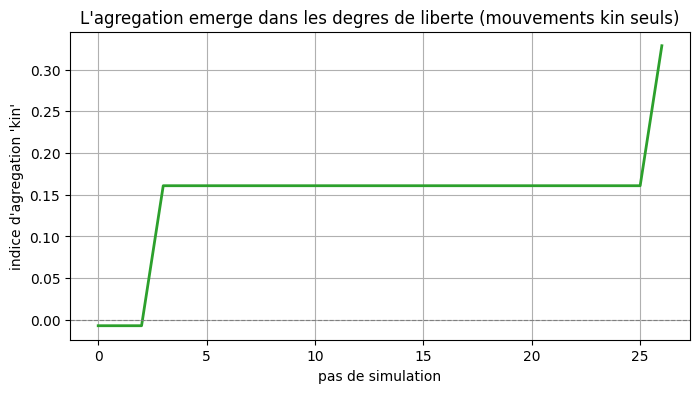

In [4]:
# --- Exemple guide : l'agregation kin isolee (tableau deja trie, kin-only) ---
vals, algos = sorted_with_mixed_algos(n_classes=6, copies=4, seed=1)   # 24 cellules
arr = KinSortingArray(vals, algotypes=algos, seed=1, kin_affinity=True).run()
courbe = m.aggregation_curve(arr.probe.algotypes)

print("Tableau deja trie par valeur, algotypes melanges (seuls les mouvements kin operent)")
print(f"  trie ? {arr.values == sorted(vals)}  | pas effectues : {arr.steps}")
print(f"  agregation : debut = {courbe[0]:+.3f}  ->  fin = {courbe[-1]:+.3f}")
print(f"  courbe non decroissante ? {all(b >= a - 1e-9 for a, b in zip(courbe, courbe[1:]))}")

plt.figure()
plt.plot(courbe, lw=2, color="tab:green")
plt.axhline(0, color="grey", lw=0.8, ls="--")
plt.xlabel("pas de simulation"); plt.ylabel("indice d'agregation 'kin'")
plt.title("L'agregation emerge dans les degres de liberte (mouvements kin seuls)")
plt.show()

**Interprétation — un ordre secondaire dans le jeu laissé par le premier.** La courbe monte **de façon monotone** : chaque mouvement « kin » augmente strictement le voisinage entre semblables, jamais ne le défait. L'agrégation s'installe **sans contrôleur global** et **sans toucher au tri** — elle vit entièrement dans les degrés de liberté que l'ordre des valeurs laisse ouverts. C'est une seconde couche d'organisation causale qui s'installe *par-dessus* la première, là où celle-ci est indifférente. Le motif est profond : la série ICT le retrouvera à l'échelle macro (émergence causale, [ICT-5](ICT-5-CausalEmergence.ipynb) / [ICT-6](ICT-6-SortingToTPM-CausalEmergence.ipynb)).

Depuis un tableau chimerique melange (seed=3) :
  kin ON  : trie = True | agregation finale = +0.143
  kin OFF : trie = True | agregation finale = -0.029


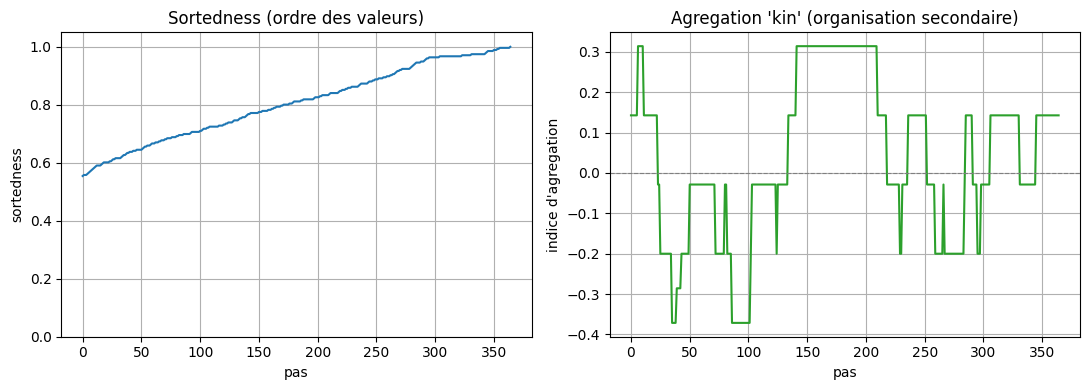

In [5]:
# --- Exemple guide : depuis un tableau chimerique melange (tri ET agregation) ---
vals, algos = value_classes(n_classes=6, copies=4, seed=3)
arr_on  = KinSortingArray(vals, algotypes=algos, seed=3, kin_affinity=True ).run()
arr_off = KinSortingArray(vals, algotypes=algos, seed=3, kin_affinity=False).run()   # controle

agg_on = m.aggregation_curve(arr_on.probe.algotypes)
srt_on = m.sortedness_curve(arr_on.probe.values)

print("Depuis un tableau chimerique melange (seed=3) :")
print(f"  kin ON  : trie = {arr_on.values  == sorted(vals)} | agregation finale = {agg_on[-1]:+.3f}")
print(f"  kin OFF : trie = {arr_off.values == sorted(vals)} | agregation finale = "
      f"{m.aggregation_index(arr_off.algotypes):+.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(srt_on, color="tab:blue"); ax1.set_title("Sortedness (ordre des valeurs)")
ax1.set_xlabel("pas"); ax1.set_ylabel("sortedness"); ax1.set_ylim(0, 1.05)
ax2.plot(agg_on, color="tab:green"); ax2.axhline(0, color="grey", lw=0.8, ls="--")
ax2.set_title("Agregation 'kin' (organisation secondaire)")
ax2.set_xlabel("pas"); ax2.set_ylabel("indice d'agregation")
plt.tight_layout(); plt.show()

**Interprétation — les deux compétences à la fois.** Partant d'un tableau chimérique entièrement mélangé, les règles enrichies livrent **simultanément** le tri global (la *sortedness* atteint 1.0) et une agrégation « kin » finale **positive** — la compétence que le modèle minimal d'ICT-2 ne pouvait pas atteindre. La courbe d'agrégation est ici **bruitée** : pendant que les valeurs migrent vers leur place, elles entraînent les algotypes avec elles et défont transitoirement des regroupements, que les mouvements kin reconstruisent ensuite. L'organisation secondaire ne se met vraiment en place qu'une fois la liberté libérée — c'est-à-dire à mesure que le tri se stabilise.

## 4. Mesure honnête : l'agrégation vit dans les degrés de liberté

Si l'agrégation émerge dans le jeu laissé par l'ordre, alors **sans jeu, pas d'agrégation**. Testons-le directement : faisons varier la **taille des classes de valeurs** (`copies`) — donc la quantité de liberté disponible — à nombre de cellules constant (24), et comparons l'agrégation finale **avec** et **sans** l'élan « kin », sur plusieurs graines.

  copies=1 (n_classes=24) : kin ON = +0.017 | kin OFF = +0.017
  copies=2 (n_classes=12) : kin ON = +0.223 | kin OFF = -0.004
  copies=3 (n_classes= 8) : kin ON = +0.313 | kin OFF = +0.019
  copies=4 (n_classes= 6) : kin ON = +0.216 | kin OFF = -0.024
  copies=6 (n_classes= 4) : kin ON = +0.280 | kin OFF = -0.103
  copies=8 (n_classes= 3) : kin ON = +0.272 | kin OFF = -0.129


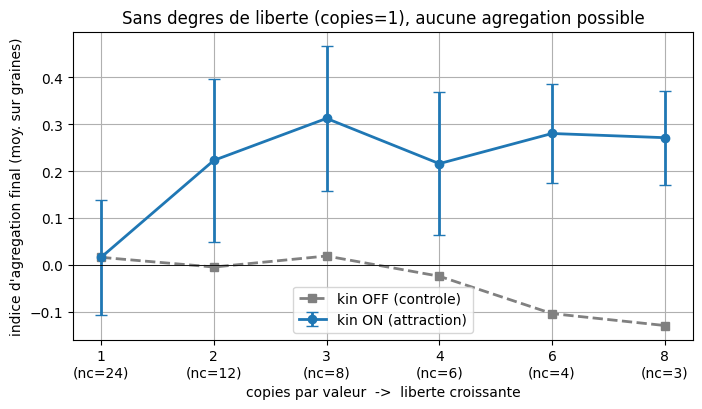

In [6]:
# --- Exemple guide : balayage de la 'liberte' disponible (taille des classes) ---
n_total, seeds = 24, range(10)
copies_list = [1, 2, 3, 4, 6, 8]
moy_on, moy_off, std_on = [], [], []
for copies in copies_list:
    nc = n_total // copies
    on, off = [], []
    for s in seeds:
        vals, algos = value_classes(nc, copies, seed=s)
        a = KinSortingArray(vals, algotypes=algos, seed=s, kin_affinity=True ).run()
        b = KinSortingArray(vals, algotypes=algos, seed=s, kin_affinity=False).run()
        assert a.values == sorted(vals) and b.values == sorted(vals)   # tri toujours preserve
        on.append(m.aggregation_index(a.algotypes))
        off.append(m.aggregation_index(b.algotypes))
    moy_on.append(np.mean(on)); std_on.append(np.std(on)); moy_off.append(np.mean(off))

for c, mo, mf in zip(copies_list, moy_on, moy_off):
    print(f"  copies={c} (n_classes={n_total // c:2d}) : kin ON = {mo:+.3f} | kin OFF = {mf:+.3f}")

plt.figure()
x = np.arange(len(copies_list))
plt.errorbar(x, moy_on, yerr=std_on, marker="o", lw=2, capsize=4, label="kin ON (attraction)")
plt.plot(x, moy_off, marker="s", lw=2, ls="--", color="grey", label="kin OFF (controle)")
plt.axhline(0, color="black", lw=0.6)
plt.xticks(x, [f"{c}\n(nc={n_total // c})" for c in copies_list])
plt.xlabel("copies par valeur  ->  liberte croissante")
plt.ylabel("indice d'agregation final (moy. sur graines)")
plt.title("Sans degres de liberte (copies=1), aucune agregation possible")
plt.legend(); plt.show()

**Interprétation — la thèse, confirmée empiriquement.** À `copies=1` (toutes les valeurs distinctes), l'ordre contraint **entièrement** le tableau : il ne reste aucun degré de liberté, et l'agrégation est **nulle, que l'élan kin soit actif ou non**. Dès que les valeurs se répètent (`copies ≥ 2`), la courbe « kin ON » décolle et croît avec la liberté disponible, tandis que le contrôle reste à zéro. La compétence d'agrégation est donc **réelle mais conditionnelle** : elle n'existe que là où l'ordre primaire laisse du jeu. Mesurer cette condition — plutôt que de proclamer « le modèle agrège » — est la discipline d'honnêteté de la série ICT.

## 5. Exercices

Trois exercices pour s'approprier le mécanisme. Les cellules de code sont des **squelettes à compléter** (`# TODO`) ; le notebook s'exécute de bout en bout même si vous ne les complétez pas.

### Exercice 1 — L'agrégation a besoin de liberté

**Objectif.** Vérifier par vous-même qu'**aucune** agrégation n'émerge sur un tableau à **valeurs distinctes**, même avec l'élan « kin » activé.

**Indices.**
- `# Etape 1` : construire un tableau à valeurs distinctes (`perm`) avec des algotypes mélangés.
- `# Etape 2` : le faire tourner avec `KinSortingArray(..., kin_affinity=True)`.
- `# Etape 3` : renvoyer `m.aggregation_index(arr.algotypes)` et le comparer à 0.

In [7]:
# Exercice 1 : l'affinite kin sans degres de liberte
def agregation_sur_valeurs_distinctes(n=24, seed=0):
    rng = np.random.default_rng(seed)
    # Etape 1 : valeurs distinctes + algotypes melanges
    # Etape 2 : KinSortingArray(..., kin_affinity=True).run()
    # Etape 3 : renvoyer l'indice d'agregation final
    result = None  # TODO etudiant
    return result

# print(agregation_sur_valeurs_distinctes())   # attendu : proche de 0

### Exercice 2 — Le coût de l'affinité

**Objectif.** L'élan « kin » ajoute-t-il du travail ? Comparer le **nombre de pas** jusqu'au point fixe avec et sans affinité, sur des tableaux à valeurs répétées.

**Indices.**
- `# Etape 1` : pour plusieurs graines, construire un `value_classes(6, 4, seed)`.
- `# Etape 2` : mesurer `arr.steps` pour `kin_affinity=True` puis `kin_affinity=False`.
- `# Etape 3` : renvoyer la moyenne des pas dans chaque régime et conclure.

In [8]:
# Exercice 2 : cout en pas de l'affinite kin
def cout_kin(n_seeds=10):
    pas_on, pas_off = [], []
    for s in range(n_seeds):
        vals, algos = value_classes(6, 4, seed=s)
        # Etape 1-2 : faire tourner les deux regimes, collecter arr.steps
        pass  # TODO etudiant
    # Etape 3 : renvoyer (moyenne pas_on, moyenne pas_off)
    result = None  # TODO etudiant
    return result

# print(cout_kin())

### Exercice 3 — Affinité répulsive : la ségrégation

**Objectif.** `KinSortingArray` accepte un paramètre `kin_sign` : `+1` attire les semblables (défaut), `-1` les **repousse** (une dynamique à la *Schelling*). Vérifier que la répulsion produit une agrégation **négative** — une ségrégation des algotypes — tout en préservant le tri.

**Indices.**
- `# Etape 1` : un `value_classes(6, 4, seed)` ; faire tourner avec `kin_sign=-1`.
- `# Etape 2` : vérifier que le tableau est trié, puis mesurer `m.aggregation_index(...)`.
- `# Etape 3` : comparer aux régimes attraction (`+1`) et neutre (`kin_affinity=False`).

In [9]:
# Exercice 3 : repulsion (segregation a la Schelling)
def trois_regimes(seed=0):
    vals, algos = value_classes(6, 4, seed=seed)
    # Etape 1-3 : agregation finale pour kin_sign=+1, kin_affinity=False, puis kin_sign=-1
    result = None  # TODO etudiant : dict {"attraction": ..., "neutre": ..., "repulsion": ...}
    return result

# print(trois_regimes())   # attendu : attraction > 0 > repulsion, tri preserve partout

## Conclusion et perspectives

ICT-4 ferme la boucle ouverte par ICT-2. Avec un jeu de règles **à peine** plus riche que le modèle minimal :

- la **réparation bidirectionnelle** guérit l'impasse chimérique (coordination) — mais n'agrège pas ;
- l'**affinité « kin »**, neutre pour l'ordre, fait **émerger** le regroupement par algotype dans les **degrés de liberté** laissés par le tri ;
- cette émergence est **réelle mais conditionnelle** : sans valeurs répétées (sans jeu), elle disparaît — ce que le balayage a montré honnêtement ;
- le **signe** de l'affinité bascule l'agrégation en **ségrégation** (Schelling), sans jamais toucher au tri.

La leçon dépasse le tri : une organisation causale **secondaire** peut s'installer dans l'indifférence d'une organisation **primaire**. C'est l'intuition que la série pousse ensuite à l'échelle macro.

### Ponts avec le reste de la série
- **[ICT-2 — Self-sorting morphogenesis](ICT-2-SelfSortingMorphogenesis.ipynb)** : le modèle minimal, ses compétences, et l'impasse que ce notebook lève.
- **[ICT-5 — Émergence causale](ICT-5-CausalEmergence.ipynb)** & **[ICT-6 — Pont tri → TPM](ICT-6-SortingToTPM-CausalEmergence.ipynb)** : la même idée — un ordre plus lisible dans les degrés de liberté du niveau inférieur — formalisée comme *causal emergence* (Hoel).
- **ICT-7 — Signatures scale-free & fractales** (à venir) : les motifs multi-échelles que ces dynamiques engendrent.

### Références
- Zhang, Goldstein & Levin, *Classical sorting algorithms as a model of morphogenesis*, Adaptive Behavior, 2025 — [arXiv:2401.05375](https://arxiv.org/abs/2401.05375).
- Jansma & Hoel, *Engineering Emergence*, arXiv 2025 (échelles causales pertinentes).
- Schelling, *Dynamic Models of Segregation*, Journal of Mathematical Sociology, 1971.